In [31]:
import pandas as pd
import tweepy

## Loading and Viewing Data

In [32]:
data = pd.read_csv("corona_tweets.csv", encoding='utf-8')
len(data)

175281

In [35]:
data.head(5)

,id,text,created_at,tweet_id,url,source,user_name,screen_name,user_location,user_verified,user_followers_count,is_quoted_tweet,quote_count,reply_count,retweet_count,favorite_count,hashtags,user_mentions
0,1,Conflicting reports. Some say he has passed aw...,2020-02-06 20:31:38.000000,1.22551742807295E+018,https://twitter.com/barbara_volkwyn/status/122...,Twitter Web App,Michael Volkwyn's sister,barbara_volkwyn,"Cape Town, South Africa",0.0,649.0,0.0,0.0,0.0,0.0,0,#Coronavirus #CoronavirusOutbreak,
1,2,Coronavirus: Reports of Brighton patient havin...,2020-02-06 20:31:38.000000,1.22551742881542E+018,https://twitter.com/Fund999ER/status/122551742...,Twitter for Android,#FundOurERServices,Fund999ER,NaN,0.0,371.0,0.0,0.0,0.0,0.0,0,#coronavirus #coronavirusuk,
2,3,People are worried about the #CoronaVirus and ...,2020-02-06 20:31:40.000000,1.22551743780789E+018,https://twitter.com/deuceohsixx/status/1225517...,Twitter for iPhone,D.E. Jones,deuceohsixx,Seattle 🇺🇸,0.0,8488.0,0.0,0.0,0.0,0.0,0,#CoronaVirus,
3,4,Complete breakdown of these meds is here:\n\nh...,2020-02-06 20:31:49.000000,1.22551747320786E+018,https://twitter.com/ContagionTrack/status/1225...,Twitter Web App,Contagion Tracker,ContagionTrack,Pandemic,0.0,1946.0,1.0,0.0,0.0,0.0,0,NaN,
4,5,May his soul rest in eternal peace,2020-02-06 20:31:50.000000,1.22551747752799E+018,https://twitter.com/thabeanstalk/status/122551...,Twitter for Android,Jack Bean,thabeanstalk,NaN,0.0,275.0,1.0,0.0,0.0,0.0,0,NaN,


In [36]:
data.screen_name.value_counts()

bitcoinconnect     4578
EcoInternetDrGB     591
TPE_connect         498
anmedia6            430
vistabuzz           390
                   ... 
harper                1
__divine1__           1
CausticChamele1       1
waveorparticle        1
xyzjayne              1
Name: screen_name, Length: 76408, dtype: int64

In [112]:
data.screen_name.nunique()

76408

## Exploratory Analysis

In [40]:
## user wise tweet count
data.screen_name.value_counts()[:5]

bitcoinconnect     4578
EcoInternetDrGB     591
TPE_connect         498
anmedia6            430
vistabuzz           390
Name: screen_name, dtype: int64

In [114]:
##checking verfied for top accounts
for accnt in ['bitcoinconnect', 'EcoInternetDrGB', 'TPE_connect', 'anmedia6', 'vistabuzz']:
   

bitcoinconnect
EcoInternetDrGB
TPE_connect
anmedia6
vistabuzz


In [119]:
data[data.screen_name.isin(['bitcoinconnect', 'EcoInternetDrGB', 'TPE_connect', 'anmedia6', 'vistabuzz'])].drop_duplicates('screen_name')

,id,text,created_at,tweet_id,url,source,user_name,screen_name,user_location,user_verified,user_followers_count,is_quoted_tweet,quote_count,reply_count,retweet_count,favorite_count,hashtags,user_mentions
20,21,Is Coronavirus Spread By People Without Sympto...,2020-02-06 20:32:32.000000,1.22551765645287E+018,https://twitter.com/bitcoinconnect/status/1225...,Clickclickme,All Express News,bitcoinconnect,NaN,0.0,951.0,0.0,0.0,0.0,0.0,0,NaN,
32,33,Woodpecker Ultrasurgery Application(3) Curetta...,2020-02-06 20:32:45.000000,1.22551770839933E+018,https://twitter.com/anmedia6/status/1225517708...,WordPress.com,Asian Netwalking Media,anmedia6,NaN,0.0,50.0,0.0,0.0,0.0,0.0,0,#Health #coronavirus,
44,45,British man who lives in Wuhan claims he defea...,2020-02-06 20:33:00.000000,1.22551777130543E+018,https://twitter.com/TPE_connect/status/1225517...,TweetDeck,www.THEPIGEONEXPRESS.com,TPE_connect,online,0.0,562.0,0.0,0.0,0.0,0.0,0,#China #British,
286,287,Chinese cities on highest virus alert: Global ...,2020-02-06 20:41:02.000000,1.22551979470898E+018,https://twitter.com/EcoInternetDrGB/status/122...,EcoInternet3,EcoInternet,EcoInternetDrGB,"New York, NY",0.0,34323.0,0.0,0.0,0.0,0.0,0,#Coronavirus #WuhanCoronavirus,
469,470,All you need to know about antivirals to treat...,2020-02-06 20:47:09.000000,1.22552133147267E+018,https://twitter.com/vistabuzz/status/122552133...,VistaBuzz,VistaBuzz,vistabuzz,United Kingdom,0.0,4.0,0.0,0.0,0.0,0.0,0,#News #China #Coronavirus #Bahcesaray #pegasus...,


In [42]:
## Unique User Count
data.screen_name.nunique()

76408

In [43]:
## Verified User Count
verified_users = []
for idx, val in data.iterrows():
    if val['screen_name'] not in verified_users and val['user_verified'] == 1:
        verified_users.append(val['screen_name'])

len(verified_users)

2930

In [111]:
## Tweet count by verfied users
len(data[data['user_verified'] == 1])

10285

In [47]:
## follower distribution
unique_users = data.drop_duplicates('screen_name')
unique_users.user_followers_count.describe().apply(lambda x: format(x, 'f'))

count       76408.000000
mean         9603.635666
std        181031.038532
min             0.000000
25%            74.000000
50%           391.000000
75%          1696.000000
max      23659780.000000
Name: user_followers_count, dtype: object

In [59]:
## hashtag counts
hashtag_counter = {}
for idx, val in data[data['hashtags'].notnull()].iterrows():
    hashtags = val['hashtags']
    for tag in hashtags.split():
        if tag.lower() in hashtag_counter:
            hashtag_counter[tag.lower()] += 1
        else:
            hashtag_counter[tag.lower()] = 0
            hashtag_counter[tag.lower()] += 1

In [121]:
hashtag_counter['#fake'], hashtag_counter['#fakenews'], hashtag_counter['#falsenews'], hashtag_counter['#hoax']

(12, 205, 1, 10)

In [65]:
## Top 10 hashtags
import operator
dict(sorted(hashtag_counter.items(), key=operator.itemgetter(1), reverse=True)[:10])

{'#coronavirus': 83545,
 '#china': 10160,
 '#wuhan': 5666,
 '#coronavirusoutbreak': 3280,
 '#virus': 3170,
 '#2019ncov': 2544,
 '#coronaviruschina': 1400,
 '#sars': 1357,
 '#breaking': 1306,
 '#ncov2019': 1215}

In [66]:
## Top user mention counts
usermention_counter = {}
for idx, val in data[data['user_mentions'].notnull()].iterrows():
    user_mentions = val['user_mentions']
    for tag in user_mentions.split():
        if tag.lower() in usermention_counter:
            usermention_counter[tag.lower()] += 1
        else:
            usermention_counter[tag.lower()] = 0
            usermention_counter[tag.lower()] += 1
dict(sorted(usermention_counter.items(), key=operator.itemgetter(1), reverse=True)[:10])

{'@who': 1678,
 '@realdonaldtrump': 1025,
 '@youtube': 781,
 '@drtedros': 471,
 '@cdcgov': 421,
 '@howroute': 330,
 '@nytimes': 300,
 '@cnn': 292,
 '@bnodesk': 250,
 '@lookner': 238}

### Retweet and Favorite Exploration

In [68]:
## We collected streaming data, so the retweet count and favorite won't be much or mostly are 0. 
##So, we developed separate script to get the retweet and favorite count after 18 days of the tweets posted.
## Due to tweet rate limitation, we couldn't get the count for all tweets, so here we will work with only 18K tweets
## In our first round of tweet collection, we found that tweet text are truncuated, so in the second round of the data collection we get the full text
## We have full text for 18K tweets
## So this part of data analysis is done on 18K tweets

In [70]:
##data merging
final_data = pd.read_csv("tweet_favor_retweet_count_1.csv", encoding='utf-8', index_col=False)
for i in range(2,19):
    temp_data = pd.read_csv("tweet_favor_retweet_count_" + str(i) + ".csv", encoding='utf-8', index_col=False)
    final_data = pd.concat([final_data, temp_data])
len(final_data)

18000

In [72]:
## Favorite Count Distribution
final_data.favorite_count.describe()

count    18000.000000
mean         8.791500
std         93.679742
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max       8737.000000
Name: favorite_count, dtype: float64

In [73]:
## Retweet Count Distribution
final_data.retweet_count.describe()

count    18000.000000
mean         4.509556
std         55.763805
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       4384.000000
Name: retweet_count, dtype: float64

#### Tweet Text Cleaning

In [85]:
import re
import string
import preprocessor as p
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [78]:
## Emoji Collections for cleaning

 
# Happy Emoticons
emoticons_happy = set([
    ':-)', ':)', ';)', ':o)', ':]', ':3', ':c)', ':>', '=]', '8)', '=)', ':}',
    ':^)', ':-D', ':D', '8-D', '8D', 'x-D', 'xD', 'X-D', 'XD', '=-D', '=D',
    '=-3', '=3', ':-))', ":'-)", ":')", ':*', ':^*', '>:P', ':-P', ':P', 'X-P',
    'x-p', 'xp', 'XP', ':-p', ':p', '=p', ':-b', ':b', '>:)', '>;)', '>:-)',
    '<3'
    ])
 
# Sad Emoticons
emoticons_sad = set([
    ':L', ':-/', '>:/', ':S', '>:[', ':@', ':-(', ':[', ':-||', '=L', ':<',
    ':-[', ':-<', '=\\', '=/', '>:(', ':(', '>.<', ":'-(", ":'(", ':\\', ':-c',
    ':c', ':{', '>:\\', ';('
    ])
 
#Emoji patterns
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
 
#combine sad and happy emoticons
emoticons = emoticons_happy.union(emoticons_sad)

In [94]:
def clean_tweets(tweet, stop_word):
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(tweet)
 
    #after tweepy preprocessing the colon left remain after removing mentions
    #or RT sign in the beginning of the tweet
    tweet = re.sub(r':', '', tweet)
    tweet = re.sub(r'‚Ä¶', '', tweet)
    #replace consecutive non-ASCII characters with a space
    tweet = re.sub(r'[^\x00-\x7F]+',' ', tweet)
 
 
    #remove emojis from tweet
    tweet = emoji_pattern.sub(r'', tweet)
 
    #if true it will remove stop words from text
    if stop_word:
        filtered_tweet = [w for w in word_tokens if not w in stop_words]
    else:
        filtered_tweet = word_tokens
 
    #looping through conditions
    filtered_words = []
    for w in filtered_tweet:
        #check tokens against stop words , emoticons and punctuations
        if w not in emoticons and w not in string.punctuation:
            filtered_words.append(w)
    return ' '.join(filtered_words), len(filtered_words)

In [87]:
import preprocessor.api as p

In [95]:
filtered_data = []
for idx, val in final_data.iterrows():
    text = val['full_text']
    clean_text = p.clean(text)
    clean_wout_stop = clean_tweets(clean_text, True)
    clean_wt_stop = clean_tweets(clean_text, False)
    val['clean_wtout_stop'] = clean_wout_stop[0].lower()
    val['clean_with_stop'] = clean_wt_stop[0].lower()
    val['count_wtout_stop'] = clean_wout_stop[1]
    val['count_with_stop'] = clean_wt_stop[1]
    
    filtered_data.append(val)
filtered_data = pd.DataFrame(filtered_data)

In [96]:
filtered_data.head()

,Unnamed: 0,tweet_id,full_text,favorite_count,retweet_count,clean_wtout_stop,clean_with_stop,count_wtout_stop,count_with_stop
0,0,1225517428072947719,Conflicting reports. Some say he has passed aw...,0,0,conflicting reports some say passed away,conflicting reports some say he has passed awa...,6,10
1,1,1225517428815417345,Coronavirus: Reports of Brighton patient havin...,0,0,coronavirus reports brighton patient virus,coronavirus reports of brighton patient having...,5,7
2,2,1225517437807886336,People are worried about the #CoronaVirus and ...,5,0,people worried rightfully virus americans real...,people are worried about the and rightfully so...,15,30
3,3,1225517473207857160,Complete breakdown of these meds is here:\n\nh...,6,2,complete breakdown meds thanks special helpers...,complete breakdown of these meds is here thank...,9,16
4,4,1225517477527990283,May his soul rest in eternal peace https://t.c...,0,0,may soul rest eternal peace,may his soul rest in eternal peace,5,7


In [97]:
filtered_data.count_with_stop.describe()

count    18000.000000
mean        18.895556
std         12.835100
min          1.000000
25%          9.000000
50%         16.000000
75%         28.000000
max         61.000000
Name: count_with_stop, dtype: float64

In [98]:
## Visualizae Word Cloud

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [101]:
tweet_All = " ".join(text for text in filtered_data.clean_wtout_stop)

In [103]:
from wordcloud import WordCloud, STOPWORDS , ImageColorGenerator

(-0.5, 399.5, 199.5, -0.5)

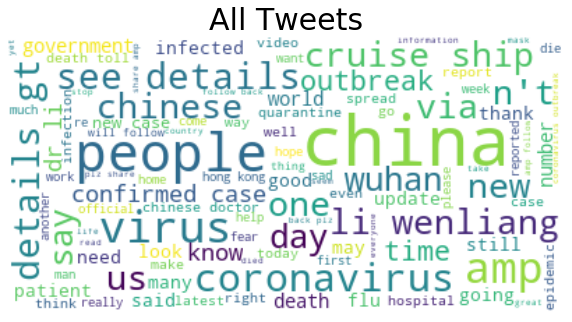

In [108]:
fig, ax = plt.subplots(1, 1, figsize  = (10,10))
wordcloud_ALL = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(tweet_All)
ax.imshow(wordcloud_ALL, interpolation='bilinear')
ax.set_title('All Tweets', fontsize=30)
ax.axis('off')